In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, silhouette_score

mush = fetch_openml('mushroom', version=1, as_frame=True)
X_raw, y_raw = mush.data, mush.target
y = (y_raw == 'p').astype(int)

cat_cols = X_raw.columns.tolist()
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])
X_encoded = preprocessor.fit_transform(X_raw)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
print(f"Размерность: {X_scaled.shape}")


Размерность: (8124, 95)


In [26]:

class POINT:
    def __init__(self, clust, vec):
        self.clust = clust
        self.vec = np.asarray(vec, dtype=float)


class CLUSTER(POINT):
    def __init__(self, clust, vec):
        super().__init__(clust, vec)
        self.N = 0

    def dist(self, p):
        return np.linalg.norm(self.vec - p.vec)

    def eval_center(self, points):
        self.N = 0
        new_center = np.zeros_like(self.vec)
        for p in points:
            if p.clust == self.clust:
                self.N += 1
                new_center += p.vec
        if self.N > 0:
            self.vec = new_center / self.N

    def delta(self, points):
        s, n = 0.0, 0
        for p in points:
            if p.clust == self.clust:
                s += np.linalg.norm(self.vec - p.vec) ** 2
                n += 1
        return s / n if n > 0 else 0.0

    def radius(self, points):
        return np.sqrt(2 * self.delta(points))


def kmeans_radius(X, n_clusters=2, max_iter=50, tol=1e-3, random_state=42):
    rng = np.random.default_rng(random_state)
    n, d = X.shape

    # Инициализация центров
    centers = X[rng.choice(n, n_clusters, replace=False)]

    labels = np.full(n, -1)

    for _ in range(max_iter):
        prev_centers = centers.copy()

        # === 1. расстояния до центров ===
        # shape: (n, k)
        dists = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)

        # === 2. первая итерация — обычный kmeans ===
        if (_ == 0):
            labels = np.argmin(dists, axis=1)
        else:
            # === 3. считаем радиусы ===
            radii = np.zeros(n_clusters)

            for k in range(n_clusters):
                mask = labels == k
                if np.any(mask):
                    # средний квадрат расстояния
                    delta = np.mean(np.sum((X[mask] - centers[k])**2, axis=1))
                    radii[k] = np.sqrt(2 * delta)
                else:
                    radii[k] = 0.0

            # === 4. применяем радиус-фильтр ===
            labels_new = np.full(n, -1)

            for k in range(n_clusters):
                mask = dists[:, k] < radii[k]
                better = (labels_new == -1) | (dists[:, k] < dists[np.arange(n), labels_new])
                labels_new[mask & better] = k

            # fallback (важно!)
            unassigned = labels_new == -1
            if np.any(unassigned):
                labels_new[unassigned] = np.argmin(dists[unassigned], axis=1)

            labels = labels_new

        # === 5. пересчёт центров ===
        for k in range(n_clusters):
            mask = labels == k
            if np.any(mask):
                centers[k] = X[mask].mean(axis=0)

        # === 6. критерий остановки ===
        shift = np.linalg.norm(centers - prev_centers, axis=1).max()
        if shift < tol:
            break

    return labels


In [27]:

def fcm(X, n_clusters=2, q=2.0, max_iter=50, tol=1e-3, random_state=42):
    rng = np.random.default_rng(random_state)
    n_points, dim = X.shape
    U = rng.random((n_points, n_clusters))
    U = U / U.sum(axis=1, keepdims=True)

    for _ in range(max_iter):
        centers = np.zeros((n_clusters, dim))
        for k in range(n_clusters):
            num = np.sum((U[:, k] ** q)[:, np.newaxis] * X, axis=0)
            den = np.sum(U[:, k] ** q)
            centers[k] = num / den if den != 0 else centers[k]
        dists = np.linalg.norm(X[:, np.newaxis, :] - centers[np.newaxis, :, :], axis=2)
        dists = np.maximum(dists, 1e-10)
        U_new = 1.0 / (dists ** (2 / (q - 1)))
        U_new = U_new / U_new.sum(axis=1, keepdims=True)
        if np.linalg.norm(U_new - U) < tol:
            U = U_new
            break
        U = U_new
    hard_labels = np.argmax(U, axis=1)
    return hard_labels, U


In [28]:

kmeans = KMeans(n_clusters=2, n_init='auto')
labels_km = kmeans.fit_predict(X_scaled)
ari_km = adjusted_rand_score(y, labels_km)
sil_km = silhouette_score(X_scaled, labels_km)

labels_rad = kmeans_radius(X_scaled, n_clusters=2)
noise = labels_rad == -1
ari_rad = adjusted_rand_score(y, labels_rad)
mask = labels_rad != -1
labs = labels_rad[mask]
if mask.sum() > 1 and np.unique(labs).size > 1:
    sil_rad = silhouette_score(X_scaled[mask], labs)
else:
    sil_rad = np.nan

labels_fcm, U_fcm = fcm(X_scaled, n_clusters=2, q=2.0)
ari_fcm = adjusted_rand_score(y, labels_fcm)
sil_fcm = silhouette_score(X_scaled, labels_fcm)

print(f"KMeans:          ARI={ari_km:.3f}, Sil={sil_km:.3f}")
print(f"KMeans+radius:   ARI={ari_rad:.3f}, Sil={sil_rad:.3f}, шум={noise.mean():.2%}")
print(f"FCM:             ARI={ari_fcm:.3f}, Sil={sil_fcm:.3f}")

KMeans:          ARI=0.619, Sil=0.105
KMeans+radius:   ARI=-0.001, Sil=0.138, шум=0.00%
FCM:             ARI=0.580, Sil=0.109


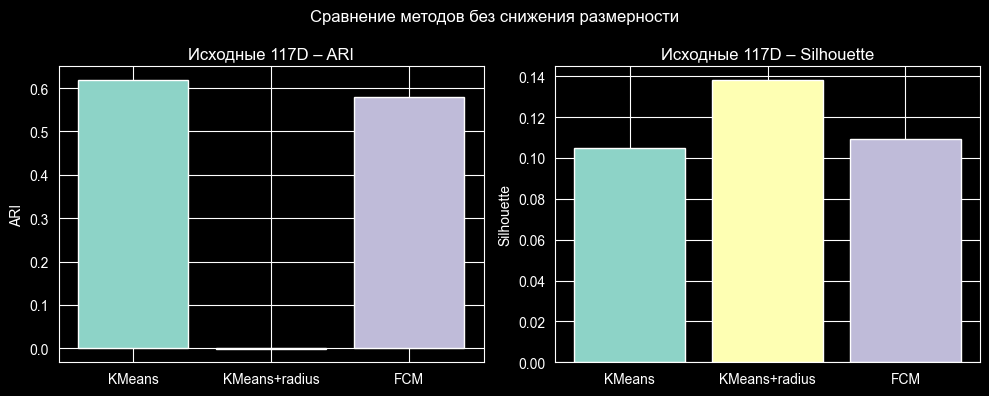

In [29]:

methods = ['KMeans', 'KMeans+radius', 'FCM']
ari_vals = [ari_km, ari_rad, ari_fcm]
sil_vals = [sil_km, sil_rad, sil_fcm]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar(methods, ari_vals, color=['C0', 'C1', 'C2'])
ax1.set_ylabel('ARI')
ax1.set_title('Исходные 117D – ARI')
ax2.bar(methods, sil_vals, color=['C0', 'C1', 'C2'])
ax2.set_ylabel('Silhouette')
ax2.set_title('Исходные 117D – Silhouette')
plt.suptitle('Сравнение методов без снижения размерности')
plt.tight_layout()
plt.show()

In [30]:

# Кластеризация после PCA (2 компоненты)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans_pca = KMeans(n_clusters=2, n_init='auto')
labels_km_pca = kmeans_pca.fit_predict(X_pca)
ari_km_pca = adjusted_rand_score(y, labels_km_pca)
sil_km_pca = silhouette_score(X_pca, labels_km_pca)

labels_rad_pca = kmeans_radius(X_pca, n_clusters=2)
noise_pca = labels_rad_pca == -1
ari_rad_pca = adjusted_rand_score(y, labels_rad_pca)
sil_rad_pca = silhouette_score(X_pca[~noise_pca], labels_rad_pca[~noise_pca]) if (~noise_pca).sum() > 1 else np.nan

labels_fcm_pca, _ = fcm(X_pca, n_clusters=2, q=2.0)
ari_fcm_pca = adjusted_rand_score(y, labels_fcm_pca)
sil_fcm_pca = silhouette_score(X_pca, labels_fcm_pca)

print(f"PCA KMeans:          ARI={ari_km_pca:.3f}, Sil={sil_km_pca:.3f}")
print(f"PCA KMeans+radius:   ARI={ari_rad_pca:.3f}, Sil={sil_rad_pca:.3f}, шум={noise_pca.mean():.2%}")
print(f"PCA FCM:             ARI={ari_fcm_pca:.3f}, Sil={sil_fcm_pca:.3f}")

PCA KMeans:          ARI=0.602, Sil=0.576
PCA KMeans+radius:   ARI=0.023, Sil=-0.161, шум=0.00%
PCA FCM:             ARI=0.541, Sil=0.586


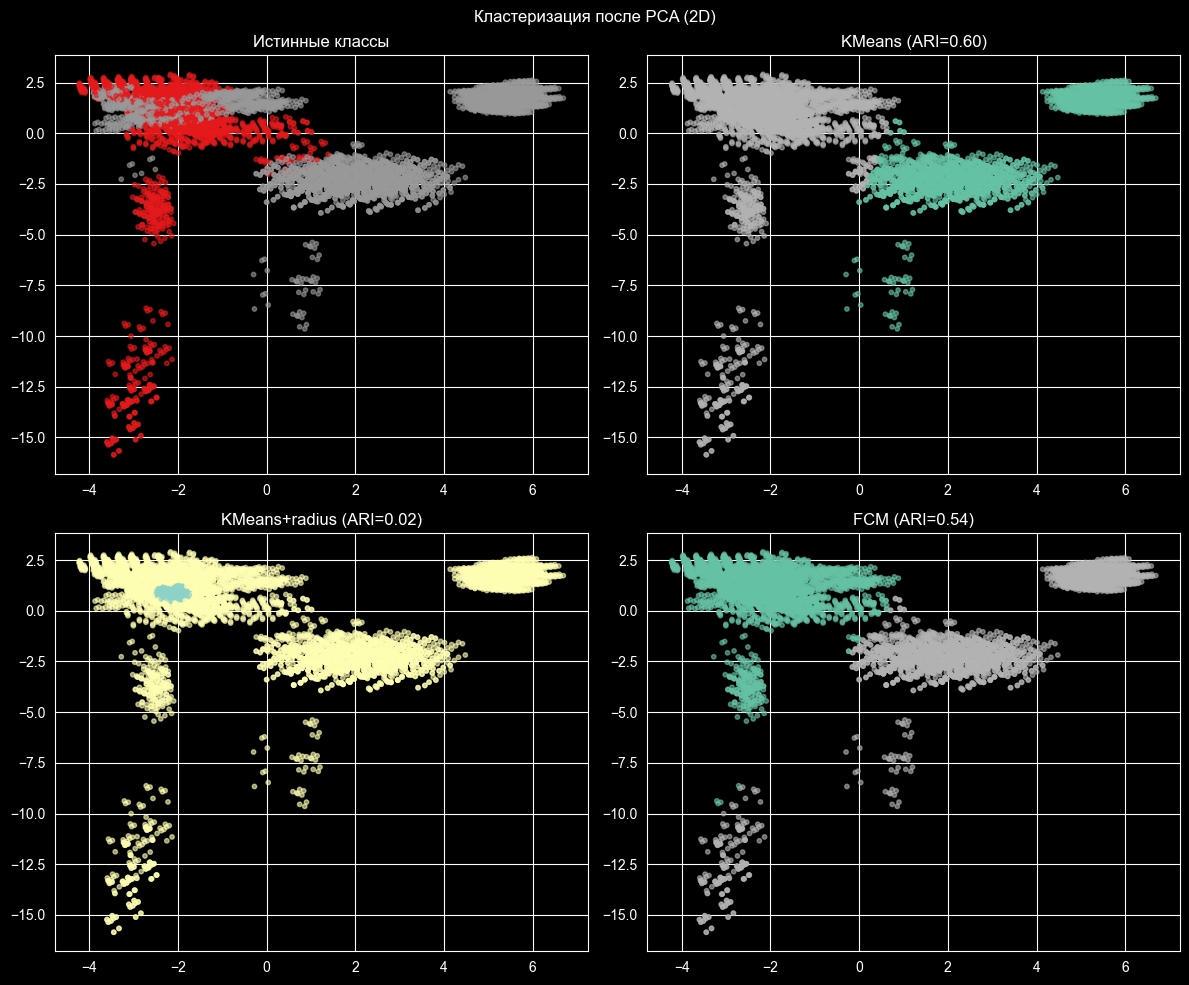

In [31]:

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='Set1', alpha=0.6, s=10)
axes[0].set_title('Истинные классы')
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km_pca, cmap='Set2', alpha=0.6, s=10)
axes[1].set_title(f'KMeans (ARI={ari_km_pca:.2f})')
colors_rad = [plt.cm.Set3(l) if l != -1 else (0.7, 0.7, 0.7) for l in labels_rad_pca]
axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_rad, alpha=0.6, s=10)
axes[2].set_title(f'KMeans+radius (ARI={ari_rad_pca:.2f})')
axes[3].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_fcm_pca, cmap='Set2', alpha=0.6, s=10)
axes[3].set_title(f'FCM (ARI={ari_fcm_pca:.2f})')
plt.suptitle('Кластеризация после PCA (2D)')
plt.tight_layout()
plt.show()

In [32]:

# Кластеризация после t‑SNE (2 компоненты)
tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled)

kmeans_tsne = KMeans(n_clusters=2,  n_init='auto')
labels_km_tsne = kmeans_tsne.fit_predict(X_tsne)
ari_km_tsne = adjusted_rand_score(y, labels_km_tsne)
sil_km_tsne = silhouette_score(X_tsne, labels_km_tsne)

labels_rad_tsne = kmeans_radius(X_tsne, n_clusters=2)
noise_tsne = labels_rad_tsne == -1
ari_rad_tsne = adjusted_rand_score(y, labels_rad_tsne)
sil_rad_tsne = silhouette_score(X_tsne[~noise_tsne], labels_rad_tsne[~noise_tsne]) if (
                                                                                          ~noise_tsne).sum() > 1 else np.nan

labels_fcm_tsne, _ = fcm(X_tsne, n_clusters=2, q=2.0)
ari_fcm_tsne = adjusted_rand_score(y, labels_fcm_tsne)
sil_fcm_tsne = silhouette_score(X_tsne, labels_fcm_tsne)

print(f"t‑SNE KMeans:          ARI={ari_km_tsne:.3f}, Sil={sil_km_tsne:.3f}")
print(f"t‑SNE KMeans+radius:   ARI={ari_rad_tsne:.3f}, Sil={sil_rad_tsne:.3f}, шум={noise_tsne.mean():.2%}")
print(f"t‑SNE FCM:             ARI={ari_fcm_tsne:.3f}, Sil={sil_fcm_tsne:.3f}")

t‑SNE KMeans:          ARI=0.007, Sil=0.333
t‑SNE KMeans+radius:   ARI=0.275, Sil=0.341, шум=0.00%
t‑SNE FCM:             ARI=0.058, Sil=0.333


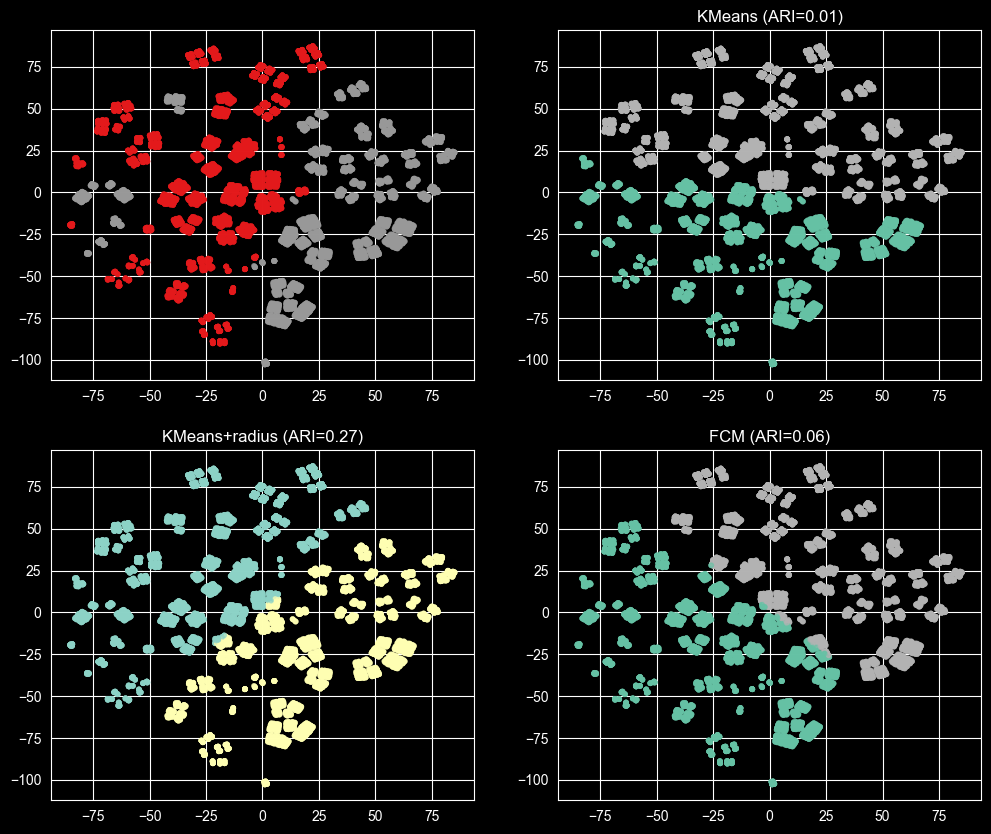

In [33]:

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='Set1', alpha=0.6, s=10)
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_km_tsne, cmap='Set2', alpha=0.6, s=10)
axes[1].set_title(f'KMeans (ARI={ari_km_tsne:.2f})')
colors_rad = [plt.cm.Set3(l) if l != -1 else (0.7, 0.7, 0.7) for l in labels_rad_tsne]
axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors_rad, alpha=0.6, s=10)
axes[2].set_title(f'KMeans+radius (ARI={ari_rad_tsne:.2f})')
axes[3].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_fcm_tsne, cmap='Set2', alpha=0.6, s=10)
axes[3].set_title(f'FCM (ARI={ari_fcm_tsne:.2f})')
plt.show()

C:\Users\Daniil\PycharmProjects\DataMine1\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


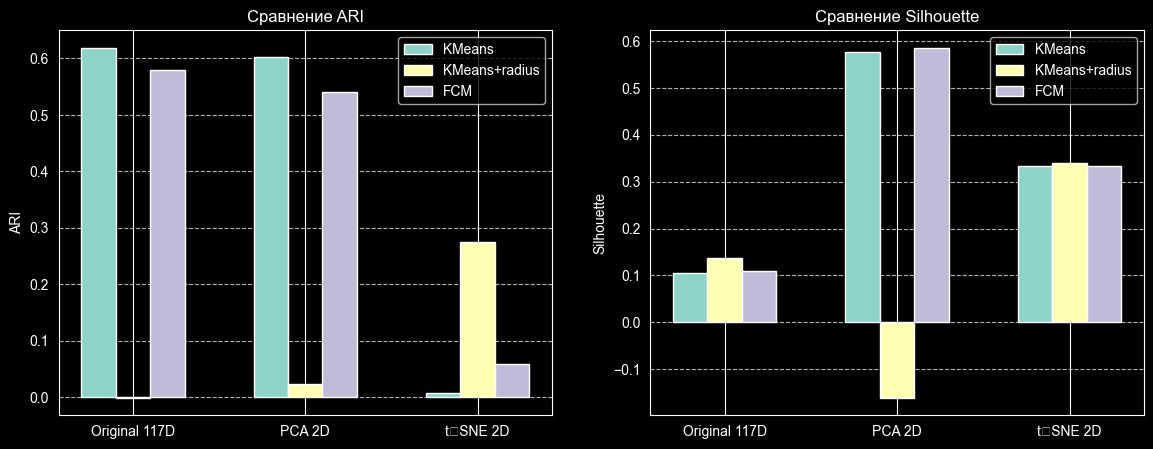

In [34]:

# Итоговое сравнение всех методов и пространств
spaces = ['Original 117D', 'PCA 2D', 't‑SNE 2D']
ari_data = {
    'KMeans': [ari_km, ari_km_pca, ari_km_tsne],
    'KMeans+radius': [ari_rad, ari_rad_pca, ari_rad_tsne],
    'FCM': [ari_fcm, ari_fcm_pca, ari_fcm_tsne]
}
sil_data = {
    'KMeans': [sil_km, sil_km_pca, sil_km_tsne],
    'KMeans+radius': [sil_rad, sil_rad_pca, sil_rad_tsne],
    'FCM': [sil_fcm, sil_fcm_pca, sil_fcm_tsne]
}

x = np.arange(len(spaces))
width = 0.2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for i, (method, vals) in enumerate(ari_data.items()):
    ax1.bar(x + i * width, vals, width, label=method)
ax1.set_xticks(x + width)
ax1.set_xticklabels(spaces)
ax1.set_ylabel('ARI')
ax1.set_title('Сравнение ARI')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

for i, (method, vals) in enumerate(sil_data.items()):
    ax2.bar(x + i * width, vals, width, label=method)
ax2.set_xticks(x + width)
ax2.set_xticklabels(spaces)
ax2.set_ylabel('Silhouette')
ax2.set_title('Сравнение Silhouette')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()